In [1]:
# =========================
# Import Libraries
# =========================

import numpy as np
import pandas as pd
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

## Loadind Dataset

In [2]:
# =========================
# Load Data
# =========================
df = pd.read_csv("../data/retail_sales.csv")

# Ensure datetime
df["date"] = pd.to_datetime(df["date"])

# Sort Data 
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-01,store_6,item_16,27,78.57,0,1,1
2,2019-01-01,store_39,item_26,47,31.60,0,1,1
3,2019-01-01,store_39,item_27,34,17.33,0,1,1
4,2019-01-01,store_39,item_28,19,35.23,1,1,1


In [3]:
# =========================
# Basic Exploration
# =========================

print("Shape:", df.shape)
print('-----------------------------------------')

print("\nColumns:", df.columns)
print('-----------------------------------------')

print("\nInfo:")
print(df.info())
print('-----------------------------------------')

print("\nDescription:")
print(df.describe())

Shape: (4565000, 8)
-----------------------------------------

Columns: Index(['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday',
       'month'],
      dtype='object')
-----------------------------------------

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype         
---  ------    -----         
 0   date      datetime64[ns]
 1   store_id  object        
 2   item_id   object        
 3   sales     int64         
 4   price     float64       
 5   promo     int64         
 6   weekday   int64         
 7   month     int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 278.6+ MB
None
-----------------------------------------

Description:
                      date         sales         price         promo  \
count              4565000  4.565000e+06  4.565000e+06  4.565000e+06   
mean   2021-07-01 12:00:00  2.926466e+01  5.399323e+01  9.999869

## Renaming specific Columns
- If needed

In [4]:
df = df.rename(columns={

    'item_id': 'product_id',

    'promo': 'promotion'

})

## Check Missing & Duplicates

In [5]:
# Check Missing
print("\nMissing values:")
print(df.isnull().sum())

print('-----------------------------------------')

# Check Duplicates
print("\nDuplicates:", df.duplicated().sum())


Missing values:
date          0
store_id      0
product_id    0
sales         0
price         0
promotion     0
weekday       0
month         0
dtype: int64
-----------------------------------------

Duplicates: 0


## Memory Optimization

In [6]:
def reduce_memory(df):
    for col in df.columns:
        if df[col].dtype == "float64":
            df[col] = df[col].astype("float32")
        elif df[col].dtype == "int64":
            df[col] = df[col].astype("int32")
    return df

df = reduce_memory(df)

In [7]:
# Fix exploding MSE
df["sales"] = np.log1p(df["sales"])

## Handle NaNs (from lagging)

In [8]:
df = df.dropna().reset_index(drop=True)

## Time Series Plot

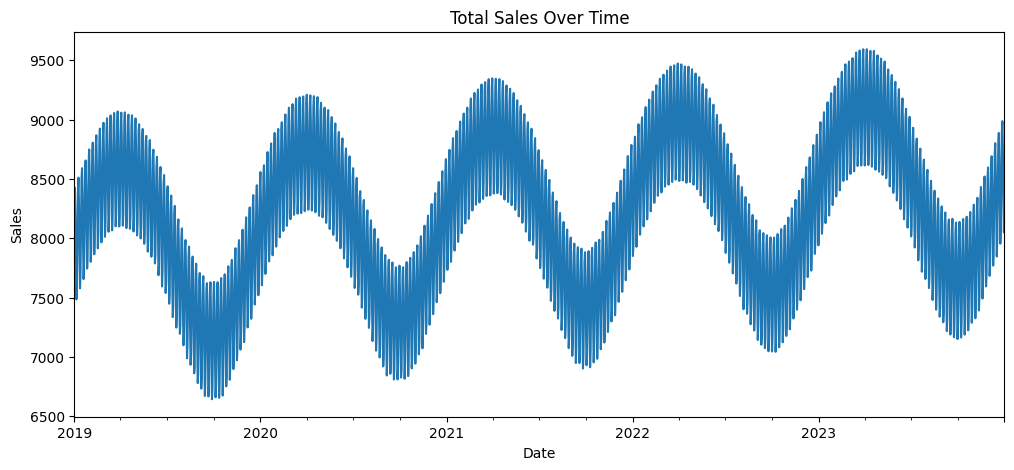

In [9]:
df.groupby('date')['sales'].sum().plot(figsize=(12, 5))

plt.title("Total Sales Over Time")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

## Top Products Analysis

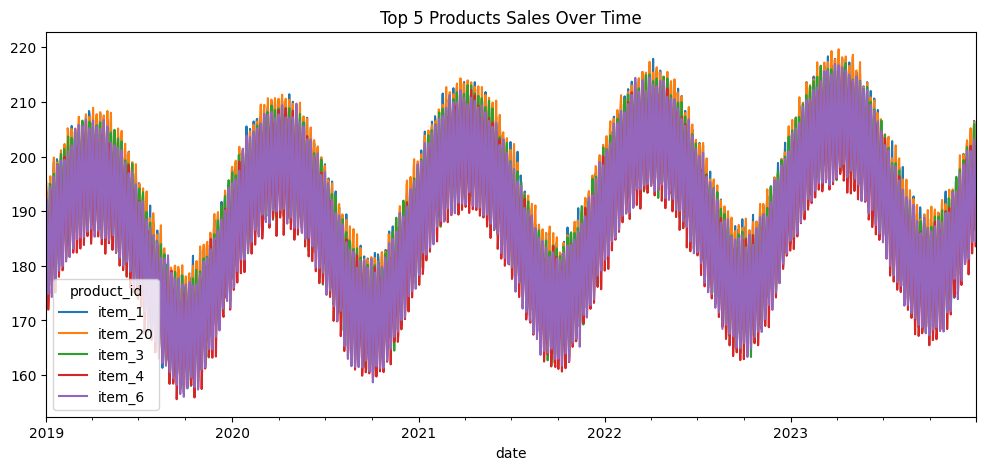

In [10]:
top_products = (

    df.groupby('product_id')['sales'].sum().sort_values(ascending=False).head(5)
)

top_df = df[df['product_id'].isin(top_products.index)]

top_df.groupby(['date', 'product_id'])['sales'] \
    .sum() \
    .unstack() \
    .plot(figsize=(12, 5))

plt.title("Top 5 Products Sales Over Time")

plt.show()

## Feature Engineering

In [11]:
# Lag features
df["lag_1"]  = df.groupby("product_id")["sales"].shift(1)
df["lag_7"]  = df.groupby("product_id")["sales"].shift(7)
df["lag_14"] = df.groupby("product_id")["sales"].shift(14)
df["lag_28"] = df.groupby("product_id")["sales"].shift(28)

# Rolling stats
df["rolling_mean_7"] = df.groupby("product_id")["sales"].shift(1).rolling(7).mean()
df["rolling_std_7"]  = df.groupby("product_id")["sales"].shift(1).rolling(7).std()

# Momentum
df["momentum"] = df["lag_1"] - df["lag_7"]

# Price dynamics
df["price_change"] = df.groupby("product_id")["price"].pct_change()

# Promotion history
df["promo_last_week"] = df.groupby("product_id")["promotion"].shift(7)

# Date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek
df["weekofyear"] = df["date"].dt.isocalendar().week.astype("int32")

## Distribution & Outliers Plots

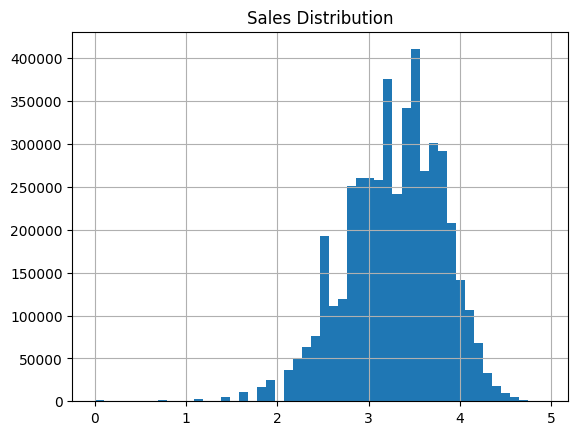

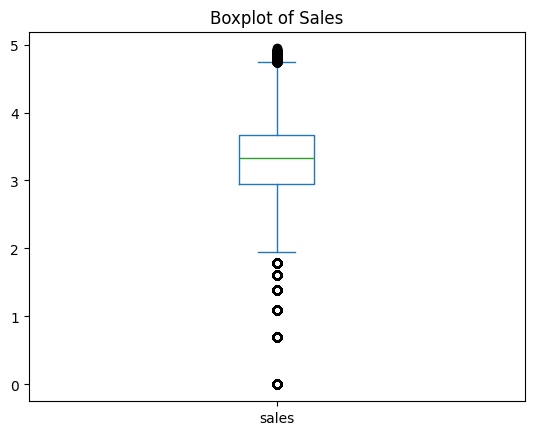

In [12]:
df['sales'].hist(bins=50)

plt.title("Sales Distribution")

plt.show()
print('\n\n')

df['sales'].plot.box()

plt.title("Boxplot of Sales")

plt.show()

## CORRELATION

In [13]:
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))


Correlation Matrix:
                    sales     price  promotion   weekday     month     lag_1  \
sales            1.000000 -0.054713   0.227170 -0.199648 -0.285569  0.814974   
price           -0.054713  1.000000  -0.127944  0.000072 -0.000026 -0.021275   
promotion        0.227170 -0.127944   1.000000 -0.000733 -0.000072  0.001088   
weekday         -0.199648  0.000072  -0.000733  1.000000 -0.000363 -0.196688   
month           -0.285569 -0.000026  -0.000072 -0.000363  1.000000 -0.285578   
lag_1            0.814974 -0.021275   0.001088 -0.196688 -0.285578  1.000000   
lag_7            0.811875 -0.020739   0.001171 -0.178733 -0.285599  0.812446   
lag_14           0.808276 -0.021445   0.000702 -0.158089 -0.285661  0.808718   
lag_28           0.801045 -0.020979   0.000837 -0.116469 -0.285784  0.801595   
rolling_mean_7   0.541973 -0.005079   0.000112 -0.334456 -0.486046  0.587361   
rolling_std_7   -0.129796  0.005881   0.000482  0.034445  0.046650 -0.168806   
momentum         0.

## Encode Categorical IDs

In [14]:
for col in ["store_id", "product_id"]:
    df[col] = df[col].astype("category").cat.codes.astype("int32")

## Train / Validation Split 

In [15]:
split_date = df["date"].quantile(0.8)

train = df[df["date"] < split_date].copy()
val   = df[df["date"] >= split_date].copy()

features = [col for col in df.columns if col not in ["sales", "date"]]

X_train, y_train = train[features], train["sales"]
X_val, y_val     = val[features], val["sales"]

cat_features = ["store_id", "product_id"]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (3650000, 19)
Validation size: (915000, 19)


## Train LightGBM ~ MAIN MODEL

In [16]:
model = lgb.LGBMRegressor(
    n_estimators=3000,    # Increased from 1000 
    learning_rate=0.03,   # # slightly smaller than 0.05
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    force_row_wise=True
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(50)]
)

[LightGBM] [Info] Total Bins 1967
[LightGBM] [Info] Number of data points in the train set: 3650000, number of used features: 19
[LightGBM] [Info] Start training from score 3.257058
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2999]	valid_0's rmse: 0.146325	valid_0's l2: 0.0214111


LGBMRegressor(colsample_bytree=0.8, force_row_wise=True, learning_rate=0.03,
              n_estimators=3000, n_jobs=-1, num_leaves=64, random_state=42,
              subsample=0.8)

## Evaluation

In [17]:
preds = model.predict(X_val)

mse = mean_squared_error(y_val, preds)

print("Validation MSE (log scale):", mse)

Validation MSE (log scale): 0.02141112549294886


## Feature Importance

In [18]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.head(20)

,feature,importance
1,product_id,55202
18,weekofyear,16868
7,lag_7,14951
0,store_id,14856
6,lag_1,14123
9,lag_28,13465
8,lag_14,13361
4,weekday,7674
10,rolling_mean_7,6490
5,month,4596


## Feature Pruning

In [19]:
# Keep only useful features
important_features = importance[importance["importance"] > 0]["feature"].tolist()

X_train = X_train[important_features]
X_val   = X_val[important_features]

# Retrain model
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(50)]
)

[LightGBM] [Info] Total Bins 1967
[LightGBM] [Info] Number of data points in the train set: 3650000, number of used features: 19
[LightGBM] [Info] Start training from score 3.257058
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2996]	valid_0's rmse: 0.146258	valid_0's l2: 0.0213915


LGBMRegressor(colsample_bytree=0.8, force_row_wise=True, learning_rate=0.03,
              n_estimators=3000, n_jobs=-1, num_leaves=64, random_state=42,
              subsample=0.8)

## Evaluation ~ After Pruning

In [20]:
preds = model.predict(X_val)

mse = mean_squared_error(y_val, preds)

print("Final MSE (log scale):", mse)

Final MSE (log scale): 0.02139146347492787


## ACCURACY

In [21]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict (log scale)
preds_log = model.predict(X_val)

# Convert back to original scale
y_val_actual = np.expm1(y_val)
preds_actual = np.expm1(preds_log)

# RMSE
rmse = np.sqrt(mean_squared_error(y_val_actual, preds_actual))

# MAE
mae = mean_absolute_error(y_val_actual, preds_actual)

# MAPE (avoid division by zero)
# business-friendly “accuracy-like” metric
mask = y_val_actual != 0
mape = (np.abs((y_val_actual[mask] - preds_actual[mask]) / y_val_actual[mask])).mean() * 100

# "Accuracy-like" metric
accuracy = 100 - mape

print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE (%):", mape)
print("Forecast Accuracy (%):", accuracy)

RMSE: 3.568948789117367
MAE : 2.8401913837111703
MAPE (%): 11.093316690412507
Forecast Accuracy (%): 88.90668330958749


## Save Model (.pkl)

In [24]:
joblib.dump({
    "model": model,
    "features": important_features
}, "lgbm_sales_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Inference Test

In [25]:
loaded = joblib.load("lgbm_sales_model.pkl")

model_loaded = loaded["model"]
features_loaded = loaded["features"]

sample = X_val[features_loaded].iloc[:5]

preds = model_loaded.predict(sample)

# Convert back to original scale
preds = np.expm1(preds)

print(preds)

[27.32054527 41.26655433 26.35012513 38.72891755  9.39030267]
